##Dataset 1 — Appliances Energy Prediction (João)


In [1]:
import pandas as pd

Fonte: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

SITUAÇÃO

A empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.


In [ ]:
# 1. Carregue a amostra no Pandas e apresente head(), shape, info() e describe().

In [4]:
df1 = pd.read_csv('/content/ex01_appliance_dataset.csv')

In [5]:
df1.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [6]:
df1.shape

(1974, 8)

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [8]:
df1.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


In [9]:
df1.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3'], dtype='object')

In [ ]:
# 2. Renomeie Appliances para Consumo_Eletrodomesticos e
# simplifique o nome de pelo menos três atributos ambientais.

In [10]:
df1.rename(columns={'Appliances': 'Consumo_Eletrodomesticos',
            'T1': 'Temperatura_1',
            'RH_1': 'Umidade_1',
            'T2': 'Temperatura_2',
            'RH_2': 'Umidade_2',
            'T3': 'Temperatura_3',
            'RH_3': 'Umidade_3'
            }, inplace=True)

In [11]:
df1.columns

Index(['Consumo_Eletrodomesticos', 'lights', 'Temperatura_1', 'Umidade_1',
       'Temperatura_2', 'Umidade_2', 'Temperatura_3', 'Umidade_3'],
      dtype='object')

In [ ]:
# 3. Determine o maior consumo de eletrodomésticos registrado na amostra.

In [12]:
df1['Consumo_Eletrodomesticos'].max()

770

In [ ]:
# 4. Calcule um limiar correspondente a 70% do valor máximo e
# crie um DataFrame contendo somente os registros acima desse limite.

In [13]:
# Limiar = 70% do valor máx!
PMAX = df1['Consumo_Eletrodomesticos'].max()
P70 = 0.7 * PMAX
limiar_max = df1[df1['Consumo_Eletrodomesticos'] > P70]
limiar_max

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333
744,740,20,19.5000,42.1333,18.2600,39.1967,19.8900,39.1933
916,750,30,22.4300,43.0000,21.9267,40.1333,21.2300,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.3900,41.9300
1026,560,0,21.0000,38.9000,19.2900,40.2000,21.7000,37.2000
1173,580,0,21.6000,34.6267,19.5000,33.7600,22.5750,34.8725


In [14]:
limiar_max.shape

(22, 8)

In [15]:
# Novo DataFrame!
df1_2 = df1[df1['Consumo_Eletrodomesticos'] > P70]
df1_2.head()

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333


In [ ]:
# 5. Conte os registros selecionados e calcule qual percentual da amostra eles representam.

In [16]:
# Quantidade de registros selecionados (consumo acima de 70% do máximo)
qtd_selecionados = len(df1_2)
qtd_total = len(df1)

df1_2_percentual = (qtd_selecionados / qtd_total) * 100

print(f'Registros selecionados: {qtd_selecionados} de {qtd_total}.')
print(f'O percentual da amostra representa {df1_2_percentual:.2f}%.')

Registros selecionados: 22 de 1974.
O percentual da amostra representa 1.11%.


In [ ]:
# 6. Calcule a temperatura média de T1 e
# crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

In [17]:
# Média - Temperatura (T1)
media_T1 = df1['Temperatura_1'].mean()
print(f'A temperatura média de T1 é {media_T1:.1f}ºC.')

A temperatura média de T1 é 21.7ºC.


In [18]:
# Novo DataFrame
df1_3 = df1[(df1['Consumo_Eletrodomesticos'] > P70) & (df1['Temperatura_1'] > media_T1)]
df1_3.head()

,Consumo_Eletrodomesticos,lights,Temperatura_1,Umidade_1,Temperatura_2,Umidade_2,Temperatura_3,Umidade_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.73,38.8633
616,570,10,24.8900,32.6667,23.5600,31.1400,23.60,30.8233
916,750,30,22.4300,43.0000,21.9267,40.1333,21.23,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.39,41.9300
1182,600,20,24.8900,48.1333,28.9175,37.9475,27.10,42.4400


In [ ]:
# 7.     Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

**Relatório Comparativo de DataFrames - Dataset 1**

Critério 1: Consumo de Eletrodomésticos > {{P70:.2f}} Wh (70% do máximo)
 **DataFrame `df2` (apenas consumo alto):**
  - Registros selecionados: {{qtd_selecionados}} de {{qtd_total}}
  - Percentual da amostra: {{df1_2_percentual:.2f}}%

Critério 2: Consumo de Eletrodomésticos > {{P70:.2f}} Wh E Temperatura_1 > {{media_T1:.2f}}°C (média)
* **DataFrame `df3` (consumo alto e temperatura alta):**
  - Registros selecionados: {{qtd_selecionados_df3}} de {{qtd_total}}
  - Percentual da amostra: {{df1_3_percentual:.2f}}%

Efeito da Inclusão da Temperatura como Segundo Critério

Ao incluir a temperatura acima da média ({{media_T1:.2f}}°C) como um segundo critério, a quantidade de registros considerados "picos de consumo" diminuiu significativamente.

* O número de registros caiu de {{qtd_selecionados}} (apenas consumo alto) para {{qtd_selecionados_df3}} (consumo alto E temperatura alta). Isso representa uma redução de {{qtd_selecionados - qtd_selecionados_df3}} registros.
* O percentual da amostra que atende a ambos os critérios é de {{df1_3_percentual:.2f}}%, em comparação com {{df1_2_percentual:.2f}}% quando consideramos apenas o consumo alto.

Essa redução indica que nem todos os picos de consumo (registros em `df1_2`) ocorrem sob condições de temperatura acima da média. A adição do critério de temperatura ajuda a refinar a seleção, focando nos eventos de alto consumo que são potencialmente influenciados por (ou ocorrem em conjunto com) temperaturas elevadas na Área 1.

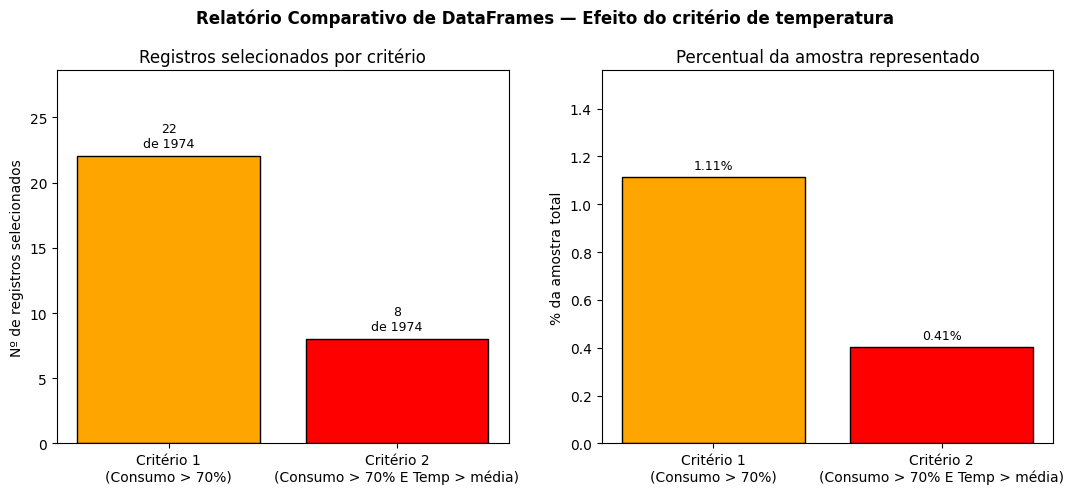

In [19]:
import matplotlib.pyplot as plt

# Valores do Critério 2 (df3), usados no relatório mas ainda não calculados antes
qtd_selecionados_df1_3 = len(df1_3)
df1_3_percentual = (qtd_selecionados_df1_3 / qtd_total) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

labels = ['Critério 1\n(Consumo > 70%)', 'Critério 2\n(Consumo > 70% E Temp > média)']
cores = ['orange', 'red']

# --- Gráfico 1: quantidade de registros selecionados ---
valores = [qtd_selecionados, qtd_selecionados_df1_3]
bars = axes[0].bar(labels, valores, color=cores, edgecolor='black')
axes[0].set_ylabel('Nº de registros selecionados')
axes[0].set_title('Registros selecionados por critério')
axes[0].set_ylim(0, max(valores) * 1.3)
for b, v in zip(bars, valores):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v}\nde {qtd_total}',
                 ha='center', va='bottom', fontsize=9)

# --- Gráfico 2: percentual da amostra ---
percentuais = [df1_2_percentual, df1_3_percentual]
bars2 = axes[1].bar(labels, percentuais, color=cores, edgecolor='black')
axes[1].set_ylabel('% da amostra total')
axes[1].set_title('Percentual da amostra representado')
axes[1].set_ylim(0, max(percentuais) * 1.4)
for b, v in zip(bars2, percentuais):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=9)

fig.suptitle('Relatório Comparativo de DataFrames — Efeito do critério de temperatura',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()